Download complete!
Map has resolution NSIDE = 1024


/tmp/ipykernel_9482/3739245832.py:46: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  new_map = hp.synfast(cl, nside, lmax=lmax, verbose=False)
/tmp/ipykernel_9482/3739245832.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


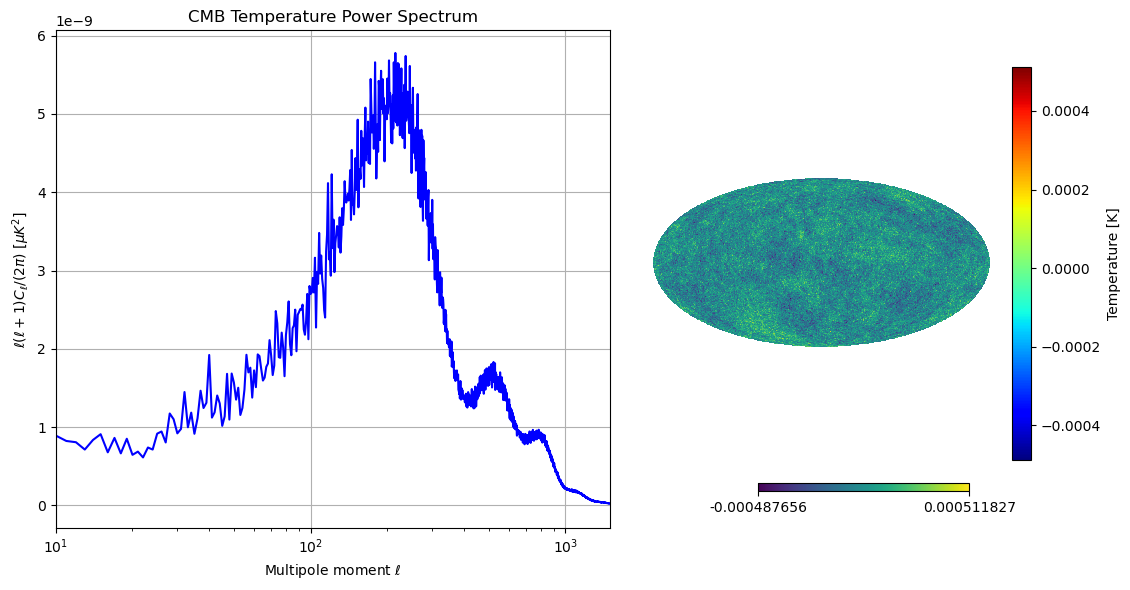

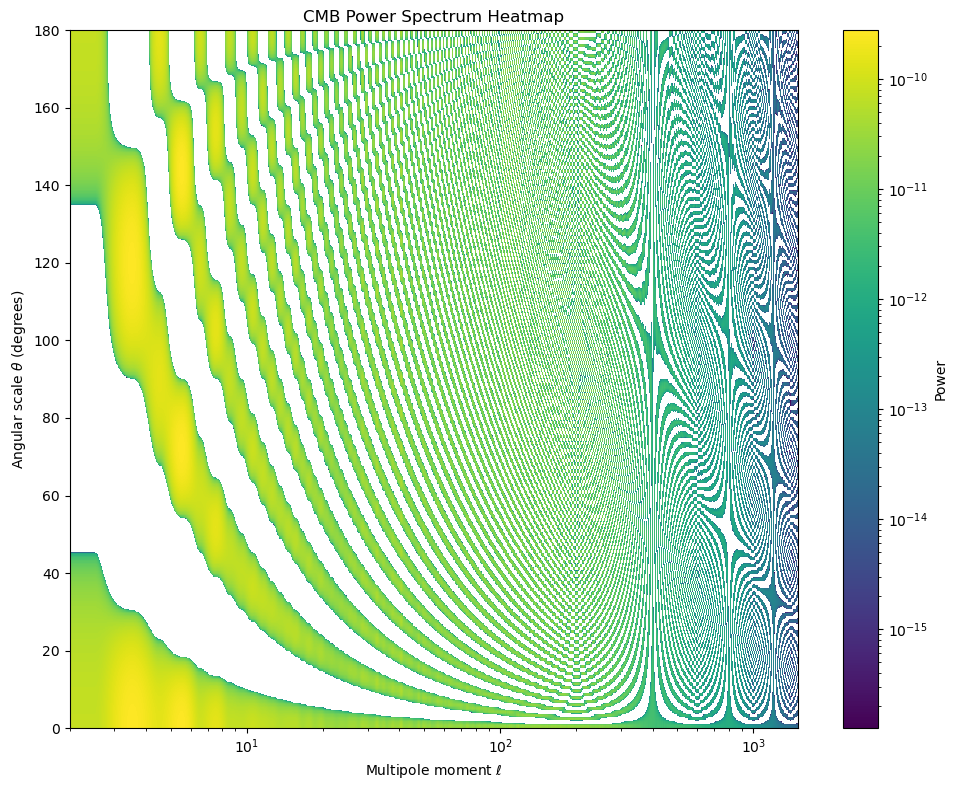

<Figure size 1000x800 with 0 Axes>

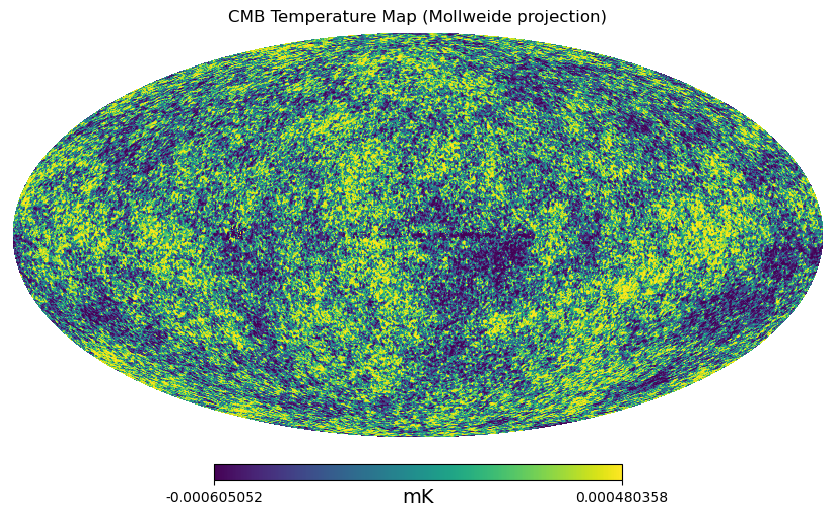

<Figure size 1000x800 with 0 Axes>

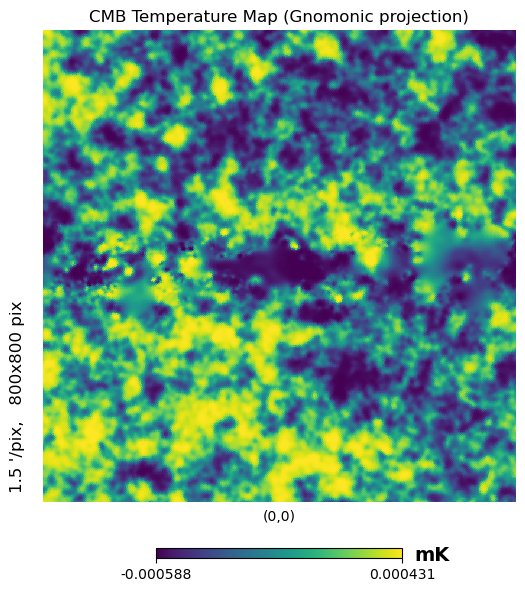

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from matplotlib.colors import LogNorm
import urllib.request
import os

# Direct download of Planck CMB map
cmb_url = "https://irsa.ipac.caltech.edu/data/Planck/release_2/all-sky-maps/maps/component-maps/cmb/COM_CMB_IQU-smica_1024_R2.02_full.fits"
map_path = "planck_cmb.fits"

# Download the file if it doesn't exist
if not os.path.exists(map_path):
    print(f"Downloading CMB map from {cmb_url}...")
    urllib.request.urlretrieve(cmb_url, map_path)
    print("Download complete!")

# Load the map (Planck SMICA CMB map, temperature only)
cmb_map = hp.read_map(map_path, field=0)  # field=0 for temperature only

# Get the resolution (NSIDE) of the map
nside = hp.get_nside(cmb_map)
print(f"Map has resolution NSIDE = {nside}")

# Calculate the power spectrum
# lmax is the maximum multipole moment to consider
lmax = 1500  # You can adjust this
cl = hp.anafast(cmb_map, lmax=lmax)

# Create l array (multipole moments)
ell = np.arange(len(cl))

# Plot the power spectrum
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("CMB Temperature Power Spectrum")
plt.plot(ell, ell * (ell + 1) * cl / (2 * np.pi), 'b-')
plt.xlabel(r"Multipole moment $\ell$")
plt.ylabel(r"$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu K^2$]")
plt.grid(True)
plt.xscale('log')
plt.xlim(10, lmax)

# Create a 2D representation of the power spectrum (heatmap)
# Generate a simulated CMB map from the power spectrum
new_map = hp.synfast(cl, nside, lmax=lmax, verbose=False)

# Plot the map in Mollweide projection
plt.subplot(122)
plt.title("CMB Temperature Map")
# Get the mollweide projection
mollview_map = hp.mollview(new_map, title="", hold=True, return_projected_map=True)
img = plt.imshow(mollview_map, cmap='jet')
plt.colorbar(img, label="Temperature [K]")
plt.axis('off')

plt.tight_layout()
plt.show()

# Optional: Create a more detailed heatmap of just the power spectrum
# This creates a 2D heatmap where x-axis is multipole and y-axis is angular scale
plt.figure(figsize=(10, 8))
plt.title("CMB Power Spectrum Heatmap")

# Create a 2D representation
l_values = np.arange(2, lmax+1)
theta_values = np.linspace(0, np.pi, 200)
power_matrix = np.zeros((len(theta_values), len(l_values)))

for i, theta in enumerate(theta_values):
    for j, l in enumerate(l_values):
        # Legendre polynomial (simplified approach)
        power_matrix[i, j] = cl[l] * (2*l+1) * np.cos(l*theta) / (4*np.pi)

plt.imshow(power_matrix, aspect='auto', cmap='viridis', 
          extent=[l_values[0], l_values[-1], 0, 180],
          origin='lower', norm=LogNorm())
plt.colorbar(label="Power")
plt.xlabel(r"Multipole moment $\ell$")
plt.ylabel(r"Angular scale $\theta$ (degrees)")
plt.xscale('log')
plt.tight_layout()
plt.show()

# You can also plot the original CMB map in different projections
plt.figure(figsize=(10, 8))
hp.mollview(cmb_map, title="CMB Temperature Map (Mollweide projection)", unit="mK", norm="hist")
plt.show()

# View a small patch of the sky in gnomonic projection
plt.figure(figsize=(10, 8))
hp.gnomview(cmb_map, rot=[0, 0], title="CMB Temperature Map (Gnomonic projection)", 
           unit="mK", norm="hist", xsize=800, ysize=800)
plt.show()